# Week 1 — Cross-Sectional Data: A Healthcare Example

**Maths for Data Science II**

A **cross-sectional dataset** is a sample of units (here: patients) observed at a **single point in time**.

Key features:

- One row per unit, **no time dimension**
- Observations are assumed **reasonably independent** (random sampling from a population)
- The observation number is just a label — the ordering carries no information

Below we simulate a small cross-sectional dataset of 200 patients measured at one clinic visit
(a "snapshot" taken in June 2026) and explore it.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
rng = np.random.default_rng(42)   # reproducible random numbers

## 2. Build the dataset

Each patient is measured **once**. Variables:

| Variable | Description |
|---|---|
| `patient_id` | observation number (label only) |
| `age` | age in years |
| `sex` | 0 = female, 1 = male (**indicator variable**) |
| `smoker` | 0 = no, 1 = yes (**indicator variable**) |
| `bmi` | body mass index |
| `sbp` | systolic blood pressure (mmHg) |
| `chol` | total cholesterol (mg/dL) |
| `cost` | annual healthcare cost (EUR) |

In [2]:
n = 200

age    = rng.integers(20, 80, size=n)
sex    = rng.integers(0, 2, size=n)
smoker = rng.binomial(1, 0.25, size=n)
bmi    = np.round(rng.normal(26, 4, size=n), 1)

# Blood pressure rises with age and BMI, and is higher for smokers
sbp  = np.round(90 + 0.45 * age + 0.9 * bmi + 6 * smoker + rng.normal(0, 8, n), 0)
chol = np.round(150 + 0.6 * age + 1.5 * bmi + 10 * smoker + rng.normal(0, 20, n), 0)
cost = np.round(np.exp(5.5 + 0.02 * age + 0.5 * smoker + rng.normal(0, 0.4, n)), 2)

df = pd.DataFrame({
    "patient_id": np.arange(1, n + 1),
    "age": age, "sex": sex, "smoker": smoker,
    "bmi": bmi, "sbp": sbp, "chol": chol, "cost": cost,
})

df.head(10)

,patient_id,age,sex,smoker,bmi,sbp,chol,cost
0,1,25,0,1,27.8,123.0,218.0,379.29
1,2,66,1,1,28.1,144.0,238.0,1724.02
2,3,59,0,0,27.1,143.0,204.0,705.53
3,4,46,1,0,20.3,142.0,205.0,506.18
4,5,45,0,0,16.8,116.0,187.0,852.54
5,6,71,0,0,26.2,148.0,207.0,1829.34
6,7,25,1,0,24.1,138.0,211.0,826.95
7,8,61,1,0,27.8,129.0,236.0,1402.38
8,9,32,0,0,28.8,120.0,177.0,444.13
9,10,25,1,0,26.6,122.0,202.0,464.56


## 3. Inspect the structure

Note there is **no date or time column**: every row is a different patient, all measured at the same moment.

In [3]:
print("Shape (rows = patients, columns = variables):", df.shape)
df.info()

Shape (rows = patients, columns = variables): (200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  200 non-null    int64  
 1   age         200 non-null    int64  
 2   sex         200 non-null    int64  
 3   smoker      200 non-null    int64  
 4   bmi         200 non-null    float64
 5   sbp         200 non-null    float64
 6   chol        200 non-null    float64
 7   cost        200 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 12.6 KB


## 4. Descriptive statistics

In [4]:
df.drop(columns="patient_id").describe().round(2)

,age,sex,smoker,bmi,sbp,chol,cost
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,50.04,0.46,0.26,25.79,136.90,220.02,877.52
std,16.49,0.50,0.44,3.99,12.41,23.57,513.20
min,20.00,0.00,0.00,14.10,104.00,146.00,216.33
25%,36.75,0.00,0.00,23.18,128.00,205.00,526.48
50%,50.00,0.00,0.00,25.85,138.00,219.00,732.11
75%,65.00,1.00,1.00,28.20,145.00,235.25,1048.55
max,79.00,1.00,1.00,36.40,177.00,304.00,3025.89


In [5]:
# Indicator variables: the mean is simply the proportion of 1s
print("Proportion male  :", df["sex"].mean())
print("Proportion smoker:", df["smoker"].mean())

Proportion male  : 0.46
Proportion smoker: 0.26


## 5. Compare groups

A typical cross-sectional question: *do smokers differ from non-smokers?*

In [6]:
df.groupby("smoker")[["age", "bmi", "sbp", "chol", "cost"]].mean().round(1)

,age,bmi,sbp,chol,cost
smoker,,,,,
0,50.1,25.8,135.1,215.8,774.3
1,49.9,25.7,142.1,232.0,1171.3


## 6. Visualise

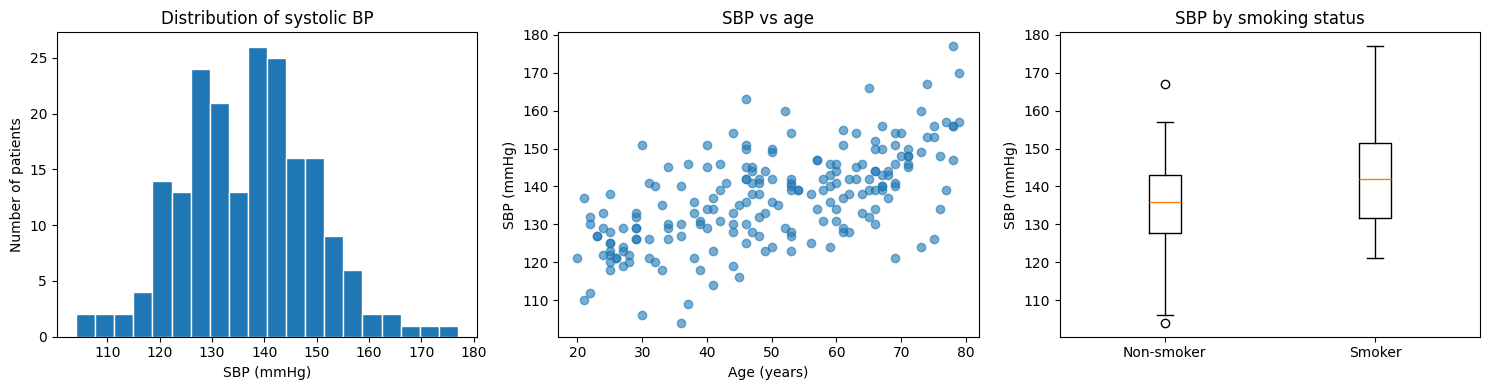

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["sbp"], bins=20, edgecolor="white")
axes[0].set_title("Distribution of systolic BP")
axes[0].set_xlabel("SBP (mmHg)")
axes[0].set_ylabel("Number of patients")

axes[1].scatter(df["age"], df["sbp"], alpha=0.6)
axes[1].set_title("SBP vs age")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("SBP (mmHg)")

axes[2].boxplot([df.loc[df.smoker == 0, "sbp"], df.loc[df.smoker == 1, "sbp"]],
                positions=[0, 1])
axes[2].set_xticks([0, 1], ["Non-smoker", "Smoker"])
axes[2].set_title("SBP by smoking status")
axes[2].set_ylabel("SBP (mmHg)")

plt.tight_layout()
plt.show()